Task 1

In [1]:
import pandas as pd

# Load dataset (IMPORTANT: use relative path)
df = pd.read_csv('../data/q1_heart_disease.csv')

# Shape
print("Shape of dataset:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# First 5 rows
df.head()

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


The dataset contains 800 rows and 12 columns, indicating a moderately sized dataset suitable for building machine learning models.

There are missing values present in the dataset, specifically 24 in the 'resting_bp' column and 32 in the 'cholesterol' column. These will need to be handled during preprocessing to avoid bias or errors in model training.

The dataset includes a mix of numerical and categorical variables. Numerical features include variables such as age, resting blood pressure, cholesterol, old peak and maximum heart rate, while categorical variables include features like chest pain type, resting ECG, and ST slope. Some variables, such as sex, exercise angina, heart disease and fasting blood sugar, are binary in nature.

The target variable is 'heart_disease', which is binary: 1 indicates the presence of heart disease, and 0 indicates absence. This confirms that the problem is a binary classification task.


Task 2

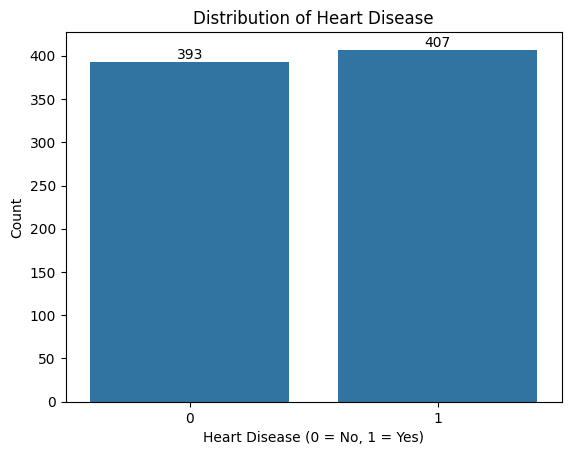

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot of target variable
ax = sns.countplot(x='heart_disease', data=df)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

# Add labels
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Show plot
plt.show()

The distribution of the target variable shows that the dataset is fairly balanced, with a similar number of observations in both classes (0 = no heart disease, 1 = presence of heart disease). The counts for both categories are close, with only a slight difference.

This indicates that there is no significant class imbalance in the dataset. As a result, standard classification models can be applied 

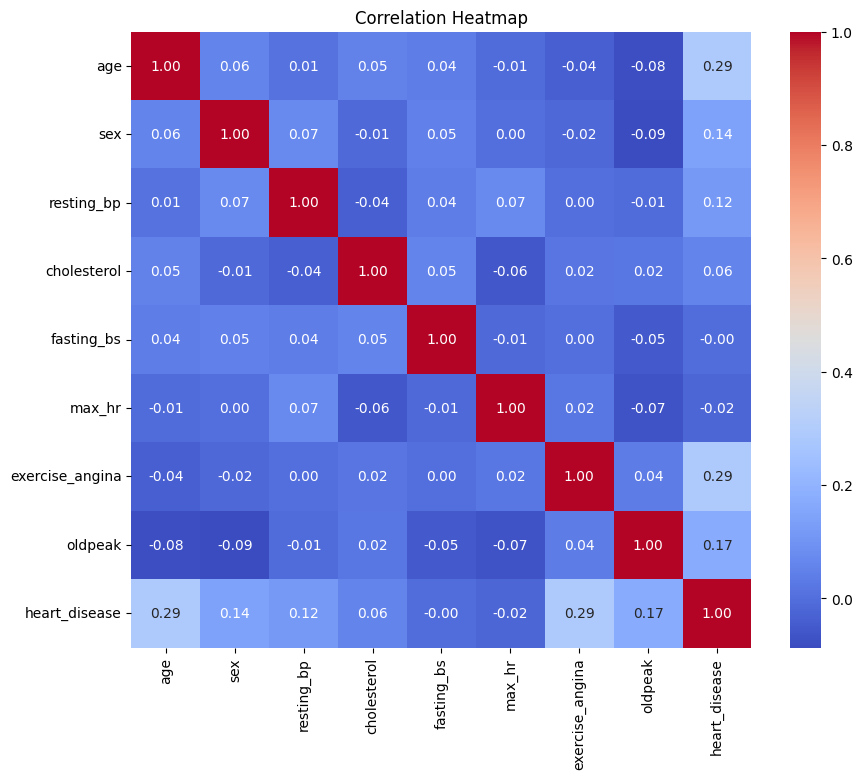

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.select_dtypes(include=['number']).corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows the relationships between numerical variables and the target variable, heart_disease.

Among all features, age and exercise_angina show the strongest positive correlation with heart disease (both around 0.29), suggesting that older individuals and those experiencing exercise-induced angina are more likely to have heart disease.

Oldpeak also shows a moderate positive correlation (0.17), indicating that higher ST depression values may be associated with increased risk of heart disease.

Sex (0.14) and resting blood pressure (0.12) show weaker positive correlations, suggesting a limited but noticeable relationship with the target variable.

On the other hand, variables such as cholesterol, fasting blood sugar, and maximum heart rate show very weak or negligible correlations with heart disease, indicating that they may not be strong individual predictors in this dataset.

Overall, no feature shows a very strong correlation (close to 1 or -1), which suggests that heart disease prediction likely depends on a combination of multiple features rather than a single dominant factor.

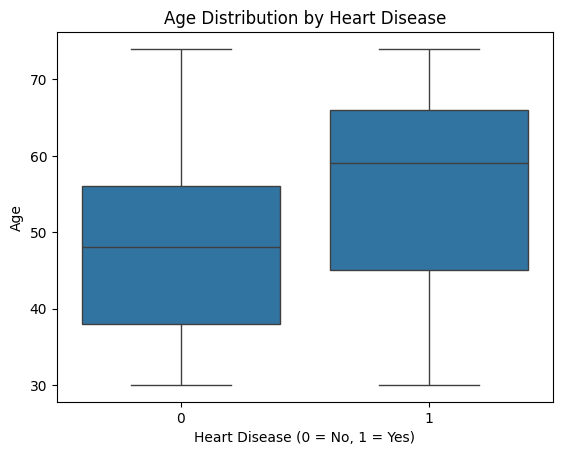

In [4]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

The boxplot shows the distribution of age across patients with and without heart disease.

It is evident that patients with heart disease (1) tend to be older on average compared to those without heart disease (0). The median age for individuals with heart disease is noticeably higher than for those without, indicating a positive relationship between age and the likelihood of heart disease.

Additionally, the distribution for the heart disease group is slightly shifted towards higher age values, suggesting that older individuals are more likely to be affected.

However, there is still some overlap between the two groups, which indicates that age alone is not a perfect predictor and should be considered alongside other features in the model.

Task 3

In [5]:
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Missing values are present in the 'resting_bp' and 'cholesterol' columns. Instead of dropping rows, which would reduce the dataset size, median imputation is used to fill the missing values. Median is preferred over mean as it is more robust to outliers and provides a better central tendency for skewed numerical data.

In [6]:
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

In [7]:
df.isnull().sum()

age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64

In [8]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
binary_cols = ['sex', 'fasting_bs', 'exercise_angina']

In [9]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

Categorical variables were one-hot encoded to convert them into a machine-readable numerical format. Binary variables such as sex, fasting blood sugar, and exercise angina were already represented as 0/1, so they were left unchanged.

The dataset was then split into training and testing sets using an 80:20 ratio, with stratification applied to preserve the class distribution of the target variable in both sets. A fixed random_state of 42 was used to ensure reproducibility.

Numerical variables were scaled using StandardScaler so that features measured on different ranges would be standardised. The scaler was fit only on the training data and then applied to the test data to avoid data leakage.

Task 4

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [15]:
print("Decision Tree:", y_pred_dt[:10])
print("Random Forest:", y_pred_rf[:10])
print("Gradient Boosting:", y_pred_gb[:10])

Decision Tree: [1 0 0 0 0 0 1 1 0 0]
Random Forest: [1 0 1 1 1 0 1 1 0 1]
Gradient Boosting: [1 0 1 1 1 0 1 1 0 1]


Task 5

In [16]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Decision Tree
print("Decision Tree")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print()

# Random Forest
print("Random Forest")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print()

# Gradient Boosting
print("Gradient Boosting")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1-score:", f1_score(y_test, y_pred_gb))

Decision Tree
Confusion Matrix:
 [[57 22]
 [25 56]]
Precision: 0.717948717948718
Recall: 0.691358024691358
F1-score: 0.7044025157232704

Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Precision: 0.7857142857142857
Recall: 0.8148148148148148
F1-score: 0.8

Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Precision: 0.775
Recall: 0.7654320987654321
F1-score: 0.7701863354037267


The performance of the three models was evaluated using precision, recall, and F1-score.

The Decision Tree model performed the weakest, with an F1-score of 0.70, indicating lower overall predictive performance compared to the other models.

The Random Forest model achieved the best results, with the highest precision (0.79), recall (0.81), and F1-score (0.80). Its higher recall suggests that it is more effective at correctly identifying patients with heart disease, which is particularly important in a medical context where missing positive cases can have serious consequences.

The Gradient Boosting model also performed well, with an F1-score of 0.77, but it was slightly lower than Random Forest across all metrics.

Overall, the Random Forest model is the best-performing model for this task, as it provides the best balance between precision and recall, making it the most reliable for predicting heart disease.

Task 6

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)


best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [18]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("Tuned Random Forest")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))

Tuned Random Forest
Confusion Matrix:
 [[59 20]
 [16 65]]
Precision: 0.7647058823529411
Recall: 0.8024691358024691
F1-score: 0.7831325301204819


Hyperparameter tuning was performed on the Random Forest model using GridSearchCV to optimise its performance. The best parameters identified were n_estimators = 100, max_depth = 10, and min_samples_split = 5.

After tuning, the model achieved an F1-score of 0.78, compared to the baseline Random Forest F1-score of 0.80. This indicates a slight decrease in performance on the test set.

This suggests that the original model was already well-optimised, and the tuned model, while more controlled in complexity, may have slightly reduced its ability to capture patterns in the data. Despite this, the performance difference is minimal, and the Random Forest model remains the best-performing model overall.

Overall, among all models tested, the Random Forest classifier demonstrated the best performance in predicting heart disease, achieving the highest F1-score and a strong balance between precision and recall. Hyperparameter tuning further validated the robustness of the model, even though it did not significantly improve performance.